In [1]:
#mounting drive so i don't have to re-upload files, they're just there in my drive and that's connected
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#adding a folder for this project in my Google Drive
!mkdir /content/drive/MyDrive/celldrift

mkdir: cannot create directory ‘/content/drive/MyDrive/celldrift’: File exists


In [1]:
!pip install scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 105.7 MB/s eta 

In [2]:
import scanpy as sc
import pandas as pd

In [3]:
#downloading spleen dataset; 906 MB, also kidney dataset; 740 MB
#originally was using figshare, but it doesn't allow Colab script downloads
#as part of its firewall, so using the CELLxGENE webpage download link
!curl -L -o /content/drive/MyDrive/celldrift/mouse_data.h5ad "https://datasets.cellxgene.cziscience.com/be2af593-fb71-4c76-85a8-3c8400783c2a.h5ad"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2430M  100 2430M    0     0  30.9M      0  0:01:18  0:01:18 --:--:-- 45.3M


In [4]:
#changing h5ad file to AnnData, the type scanpy uses
adata = sc.read_h5ad('/content/drive/MyDrive/celldrift/mouse_data.h5ad')

In [5]:
#remember, .obs is still a pandas dataframe and you can do the usual pd operations with it
#"mask" because this line filters all the data that came in one file to just the information about the spleen

#.X cells as rows genes as columns. Expression data
#.obs facts about cells as columns, eg age, sex, origin tissue. No gene info, just describe rows of .X
#.var is one row per gene describing the columns of .X

#using .obs right now because that has the cell information which I can use to decide what groups I want to analyze
#from there, i do the actual data analysis on the .X

#mask isn't actually doing anything directly; that's just the true false filter you apply to adata to actually get the data; it's prework
spleen_mask = adata.obs['tissue'] == 'spleen'
#copying so that the original data isn't connected, and i can change it without affecting the original
spleen_data = adata[spleen_mask].copy()
#spleen_data.obs['cell_type'].value_counts()

In [6]:
#visualizing data distribution and saving it in csvs to my drive
per_age_cell_counts = pd.crosstab(spleen_data.obs['cell_type'], spleen_data.obs['age'])
per_age_cell_counts.to_csv('/content/drive/MyDrive/celldrift/celltype_by_age.csv')

per_donor_cell_counts = pd.crosstab(spleen_data.obs['cell_type'], spleen_data.obs['donor_id'])
per_donor_cell_counts.to_csv('/content/drive/MyDrive/celldrift/celltype_by_donor.csv')

per_age_donor_numbers = pd.crosstab(spleen_data.obs['age'], spleen_data.obs['donor_id'])
per_age_donor_numbers.to_csv('/content/drive/MyDrive/celldrift/age_by_donor.csv')

In [7]:
#taking original, raw data before TMS authors processed it; so before normalization, log-transformation, and scaling
#so processing is completely up to me, then saving the raw data to my drive
spleen_raw = spleen_data.raw.to_adata()
spleen_raw.write_h5ad('/content/drive/MyDrive/celldrift/spleen_raw.h5ad')

In [8]:
#normalizing the data; each cell was sequenced by a different method that determines how much of the gene
#shows up on measurement; this looks like some cells use some genes a lot more, but that's because the total
#number of genes is greater too. So, using scanpy to scale everything to a total of 10,000, and rework individual gene counts
#proportionately

#this modifies directly rather than creating a new object
sc.pp.normalize_total(spleen_raw, target_sum = 1e4)
print(spleen_raw.X[:5, :5])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6 stored elements and shape (5, 5)>
  Coords	Values
  (1, 0)	4.342793941497803
  (2, 0)	0.008843117393553257
  (2, 3)	0.061901818960905075
  (3, 0)	0.5403209328651428
  (3, 4)	4.534592151641846
  (4, 4)	3.617143154144287


In [9]:
#filtering to only bcells and only tcells
bcell_mask = spleen_raw.obs['cell_type'] == 'B cell'
bcell_data = spleen_raw[bcell_mask].copy()

tcell_mask = spleen_raw.obs['cell_type'].isin(['CD4-positive, alpha-beta T cell','CD8-positive, alpha-beta T cell' ])
tcell_data = spleen_raw[tcell_mask].copy()

In [10]:
#turns numbers into True/False; is the number of times this gene was expressed in this cell greater than zero or not,
#and this operation run across the whole matrix
bcell_detected = bcell_data.X > 0
#axis equals zero counts the number of cells each gene was found in
bcell_ncells_with_gene = bcell_detected.sum(axis=0)

#this was one row with a lot of columns; each column being a gene
#flattening that into one flat list so it's plottable
bcell_ncells_with_gene = bcell_ncells_with_gene.A1
print(bcell_ncells_with_gene)

#number of genes that are being reasonably expressed over the total number of cells
bcell_fraction = bcell_ncells_with_gene/bcell_detected.shape[0]

[1387    0   33 ...  156    1    0]


In [11]:
#repeating to get the same fraction for T cells
tcell_detected = tcell_data.X > 0

tcell_ncells_with_gene = tcell_detected.sum(axis=0)

tcell_ncells_with_gene = tcell_ncells_with_gene.A1
print(tcell_ncells_with_gene)

#number of genes that are being reasonably expressed over the total number of cells
tcell_fraction = tcell_ncells_with_gene/tcell_detected.shape[0]

[349   0   5 ...  31   0   1]


In [12]:
#masking to get correlation factor; first filtering by fraction of cells gene expressed in,
#then for the genes that passed that calculating correlation
from scipy.stats import spearmanr, pearsonr
correlation_mask = (bcell_fraction > 0.01) |  (tcell_fraction > 0.01)
#printing number of genes passed; 11485 passed, 54.6% of total spleen genes
print(correlation_mask.sum())

#r is correlation coefficient; -1 to 1, p is the likelihood this result could occur by chance
#pearson is linear; doesn't work for variables that are correlated on a curve
#still, calculating this and the spearman (the one that works regardless)
#pearson gave 0.8858 correlation, 89% by convention
r_pearson, p_pearson = pearsonr(bcell_fraction[correlation_mask], tcell_fraction[correlation_mask])
print(r_pearson)

#now spearman; returned 0.8739, 87% by convention
r_spearman, p_spearman = spearmanr(bcell_fraction[correlation_mask], tcell_fraction[correlation_mask])
print(r_spearman)

#the fact that spearman and pearson don't strongly diverge indicates that the relationship is largely linear;
#also that outlier genes are not really affecting the correlation

11485
0.8858223195047279
0.8739153117709338


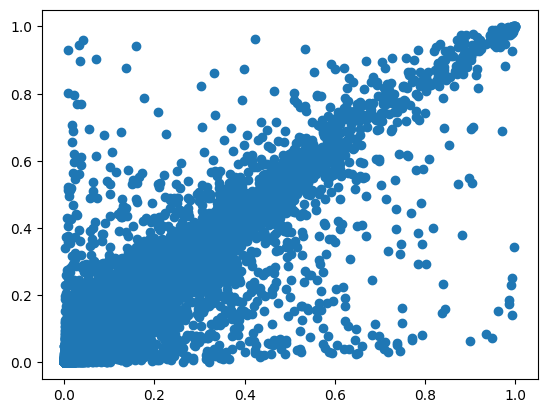

In [13]:
#now looking at the plot to see overlap between genes expressed a lot in bcells and genes expressed a lot in tcells
#turns out they differ quite a bit, so i'm going to take the genes most expressed separately in bcell and tcell,
#then get the intersection for my analysis
import matplotlib.pyplot as plt
plt.scatter(bcell_fraction, tcell_fraction)
plt.savefig('/content/drive/MyDrive/celldrift/bcell_vs_tcell_genes.png', dpi=150)
plt.show()

In [14]:
#now filtering by genes; some genes are hard to detect by sequencing machines, and calculating coefficient of variation/CV for those
#doesn't measure actual gene expression, just measures sequencer capability. So, filtering to only genes that have  20% expression rate
#in both cell types; that comes out to 2428 genes, an 88% reduction of the total 21,025 spleen genes
analysis_mask = (bcell_fraction > 0.2) & (tcell_fraction > 0.2)
print(analysis_mask.sum())

#keeping all cells, but filtering from original spleen data to just the genes that passed my filtering
analysis_genes = spleen_raw[:, analysis_mask].copy()
analysis_genes.write_h5ad('/content/drive/MyDrive/celldrift/spleen_filtered.h5ad')

2428


In [15]:
#now rebuilding the b cell and t cell subset from the filtered data
#note; same variable names, but these are now the filtered versions
bcell_mask = analysis_genes.obs['cell_type'] == 'B cell'
bcell_data = analysis_genes[bcell_mask].copy()

tcell_mask = analysis_genes.obs['cell_type'].isin(['CD4-positive, alpha-beta T cell','CD8-positive, alpha-beta T cell' ])
tcell_data = analysis_genes[tcell_mask].copy()

#bcell has 2851 passed cells, tcell 768, bot 2428 genes
print(bcell_data.shape)
print(tcell_data.shape)

(2851, 2428)
(768, 2428)


In [16]:
#bcell_data.obs['donor_id'].value_counts()
tcell_data.obs['donor_id'].value_counts()

donor_id
18_47_F    87
3_38_F     72
24_60_M    71
24_58_M    70
3_39_F     66
3_9_M      63
18_53_M    63
3_8_M      56
3_11_M     56
24_61_M    48
24_59_M    46
3_10_M     37
18_45_M    33
Name: count, dtype: int64

In [95]:
#setting a random seed for downsampling
import numpy as np
seed = 3
np.random.seed()

#writing a function that'll downsize all data randomly to fit the lowest count
def downsample_cells(cell_subset, n_cells):
  #this dict key/value donorid/list of cell indices. So it would be {1:[33, 56, 78], 2: [34, 45, 55]}
  mouse_cellindices_dict = {}
  #n_cells is the number downsampling to; for b-cells, 116 is the lowest count, for t-cells 33
  #looping over each donor in the category

  donorid_list = cell_subset.obs['donor_id'].unique()
  for donorid in donorid_list:
    donor_mask = cell_subset.obs['donor_id'] == donorid
    #converting true/false into usable indices, then randomly picking 116 of those; [0] pulls array out of tuple
    donor_indices = np.where(donor_mask)[0]

    #taking a random 116 of the donor's indices, replace = False because i don't want same cell chosen twice
    chosen_indices = np.random.choice(donor_indices, n_cells, replace=False)
    mouse_cellindices_dict[donorid] = chosen_indices

  return mouse_cellindices_dict

downsampled_bcell_dict = downsample_cells(bcell_data, 116)
downsampled_tcell_dict = downsample_cells(tcell_data, 33)

In [96]:
def get_cvs(cell_subset,downsampled_dict):
  #cv_dict format donor id key, cv array value
  cv_dict = {}
  mean_dict={}
  for donorid in downsampled_dict.keys():
    positions = downsampled_dict[donorid]
    mouse_random_cells = cell_subset[positions]

    dense_mouse_cells = mouse_random_cells.X.toarray()
    #axis equals zero just means we're operating on the genes' expression
    mean = dense_mouse_cells.mean(axis=0)
    sd = dense_mouse_cells.std(axis=0, ddof = 1)
    cv = sd/mean
    cv_dict[donorid] = cv
    mean_dict[donorid] = mean
  return cv_dict, mean_dict

bcell_cvs,bcell_means = get_cvs(bcell_data, downsampled_bcell_dict)
tcell_cvs,tcell_means = get_cvs(tcell_data, downsampled_tcell_dict)

/tmp/ipykernel_5311/1543203427.py:13: RuntimeWarning: invalid value encountered in divide
  cv = sd/mean


In [97]:
bcell_cvs_df = pd.DataFrame(bcell_cvs)
tcell_cvs_df = pd.DataFrame(tcell_cvs)
bcell_means_df = pd.DataFrame(bcell_means)
tcell_means_df = pd.DataFrame(tcell_means)

print(tcell_means_df.shape)
#checking the sum total of how many genes are missing in all of the cells in the bcell data; 5
missing_genes_b = bcell_cvs_df.isna().any(axis=1)
#17 for tcells; more because there are less cells, so more likely that all cells miss the gene
missing_genes_t = tcell_cvs_df.isna().any(axis=1)

#using the "or" tag; essentially combining the missing genes in both and taking out the repeats so it's one unique list
#counted; 21 unique missing genes in at least one mouse
missing_genes = missing_genes_b | missing_genes_t

#this is a flip; clean_genes are everything that isn't tagged as missing_genes
clean_genes = ~missing_genes
b_cv_clean = bcell_cvs_df[clean_genes]
t_cv_clean = tcell_cvs_df[clean_genes]
b_mean_clean = bcell_means_df[clean_genes]
t_mean_clean = tcell_means_df[clean_genes]

b_cv_clean.to_csv('/content/drive/MyDrive/celldrift/bcell_cv_per_mouse.csv')
t_cv_clean.to_csv('/content/drive/MyDrive/celldrift/tcell_cv_per_mouse.csv')
b_mean_clean.to_csv('/content/drive/MyDrive/celldrift/bcell_mean_person_mouse')
t_mean_clean.to_csv('/content/drive/MyDrive/celldrift/tcell_mean_person_mouse')

(2428, 13)


In [98]:
print(bcell_cvs_df.median(axis=0))

18_47_F    1.732049
18_45_M    2.655779
18_53_M    2.418009
24_59_M    2.645885
24_60_M    2.555946
24_61_M    1.860614
24_58_M    2.536822
3_39_F     2.199199
3_9_M      2.306943
3_8_M      2.441783
3_10_M     2.249575
3_11_M     3.137707
3_38_F     2.172097
dtype: float32


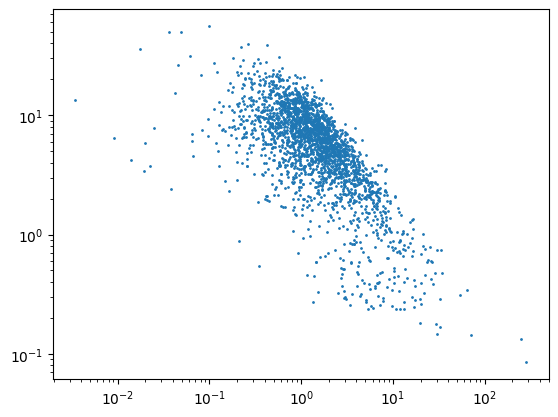

In [99]:
#squaring gives variance, which is addable
#log scale because treats tenfold as equivalent; scales proportionally rather than literally
y = b_cv_clean['3_8_M'] ** 2
x = b_mean_clean['3_8_M']

plt.scatter(x,y,s=1)
plt.xscale('log')
plt.yscale('log')
plt.show()

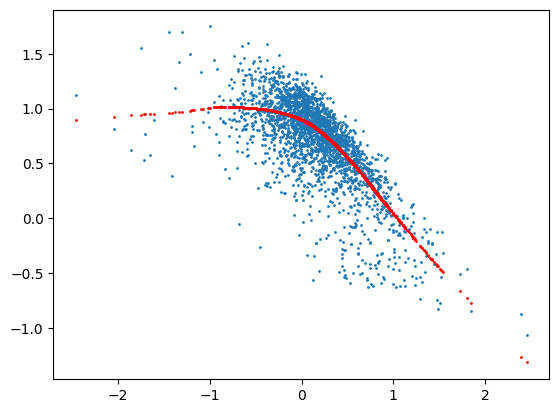

In [100]:
#relogging because lowess (the curve-fitting that gives me residuals, how much more/less variable a gene is
#than its expression rate would suggest) doesn't care if the plot is scaled, the actual numbers have to be too
log_y = np.log10(y)
log_x = np.log10(x)
from statsmodels.nonparametric.smoothers_lowess import lowess
#keeping genes in the order they came in so it's easier to operate on them later
#frac tracks neighborhood width; lowess does many small local line-fittings so it can produce a curve
#that fits; neighborhood width just dictates HOW local; so 0.7 would be basically the entire graph, 0.05 would be just the nearby 120 genes
#too wide risks ignoring curves, too small risks overaccounting for noise
fitted = lowess(log_y, log_x, frac=0.5, return_sorted = False)
comparison = lowess(log_y, log_x, frac=0.5, return_sorted = False)
plt.scatter(log_x, log_y, s=1)
plt.scatter(log_x, fitted, s=1, color='red')
plt.savefig('/content/drive/MyDrive/celldrift/lowess_residual_fit.png')
plt.show()

In [101]:
lownw_residual = log_y - fitted
highnw_residual = log_y - comparison
r_pearson, p_pearson = pearsonr(lownw_residual, highnw_residual)
print(r_pearson)

1.0


In [102]:
def get_residuals(cv_df, mean_df):
  #formatted {donorid: residuals array, donorid: residuals array, etc}
  return_df = {}
  for donor in cv_df.columns:
    y = cv_df[donor] ** 2
    x = mean_df[donor]
    log_y = np.log10(y)
    log_x = np.log10(x)
    fitted = lowess(log_y, log_x, frac = 0.5, return_sorted = False)
    residuals = log_y - fitted
    return_df[donor] = residuals

  return return_df

bcell_residuals = get_residuals(b_cv_clean, b_mean_clean)
tcell_residuals = get_residuals(t_cv_clean, t_mean_clean)
bcell_residuals = pd.DataFrame(bcell_residuals)
tcell_residuals = pd.DataFrame(tcell_residuals)
print(bcell_residuals.median(axis=0))
print(tcell_residuals.median(axis=0))

18_47_F    0.002762
18_45_M    0.003199
18_53_M    0.007002
24_59_M    0.004380
24_60_M    0.006263
24_61_M    0.003018
24_58_M    0.003415
3_39_F     0.010661
3_9_M      0.007188
3_8_M      0.011509
3_10_M     0.005491
3_11_M     0.008608
3_38_F     0.011696
dtype: float64
18_45_M    0.008197
18_47_F    0.000971
18_53_M    0.010063
24_59_M    0.007022
24_60_M    0.006953
24_61_M    0.003545
24_58_M    0.007544
3_39_F     0.006929
3_38_F     0.009986
3_9_M      0.007949
3_11_M     0.009419
3_10_M     0.006619
3_8_M      0.016384
dtype: float64


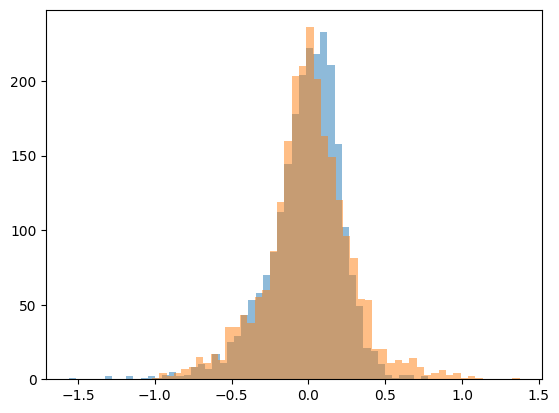

In [103]:
plt.hist(bcell_residuals['3_11_M'], bins = 50, alpha = 0.5)
plt.hist(bcell_residuals['24_61_M'], bins = 50, alpha = 0.5)
plt.show()

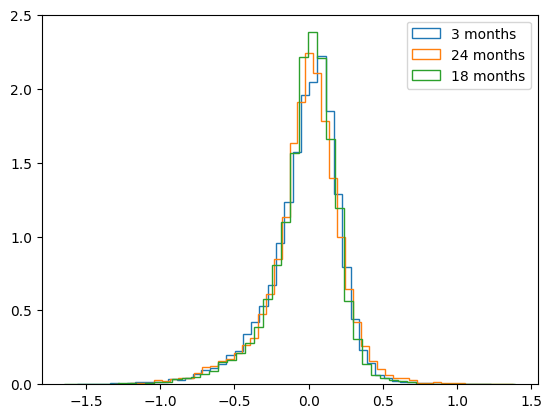

In [104]:
three_month_olds = []
twenty_four_month_olds = []
eighteen_month_olds=[]
for name in bcell_residuals.columns:
  if name.startswith('3_'):
    three_month_olds.append(name)
  elif name.startswith('24_'):
    twenty_four_month_olds.append(name)
  else:
    eighteen_month_olds.append(name)

#making a plot with bcell three month olds vs eighteen month vs twentyfourmontholds; same as before but with groups rather than individual mice
three_month_olds = bcell_residuals[three_month_olds].values.ravel()
twenty_four_month_olds = bcell_residuals[twenty_four_month_olds].values.ravel()
eighteen_month_olds = bcell_residuals[eighteen_month_olds].values.ravel()

plt.hist(three_month_olds, bins=50, histtype = 'step', density = True, label = '3 months')
plt.hist(twenty_four_month_olds, bins=50, histtype = 'step',density = True, label = '24 months')
plt.hist(eighteen_month_olds, bins=50, histtype = 'step' ,density = True, label = '18 months')

plt.savefig(f'/content/drive/MyDrive/celldrift/{seed}_bcell_group_oldvyoung_hist.png')
plt.legend()
plt.show()

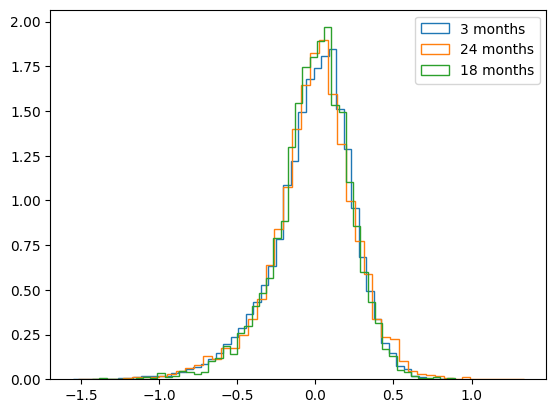

In [105]:
three_month_olds = []
twenty_four_month_olds = []
eighteen_month_olds=[]
for name in tcell_residuals.columns:
  if name.startswith('3_'):
    three_month_olds.append(name)
  elif name.startswith('24_'):
    twenty_four_month_olds.append(name)
  else:
    eighteen_month_olds.append(name)

#making a plot with bcell three month olds vs eighteen month vs twentyfourmontholds; same as before but with groups rather than individual mice
three_month_olds = tcell_residuals[three_month_olds].values.ravel()
twenty_four_month_olds = tcell_residuals[twenty_four_month_olds].values.ravel()
eighteen_month_olds = tcell_residuals[eighteen_month_olds].values.ravel()

plt.hist(three_month_olds, bins=50, histtype = 'step', density = True, label = '3 months')
plt.hist(twenty_four_month_olds, bins=50, histtype = 'step',density = True, label = '24 months')
plt.hist(eighteen_month_olds, bins=50, histtype = 'step' ,density = True, label = '18 months')

plt.savefig(f'/content/drive/MyDrive/celldrift/{seed}_tcell_group_oldvyoung_hist.png')
plt.legend()
plt.show()